In [2]:
import yfinance as yf
import pandas as pd

wti = yf.download('CL=F', period="5y")
brent = yf.download('BZ=F', period="5y")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
wti.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


In [4]:
wti.tail()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2026-05-20,98.260002,104.449997,96.940002,104.120003,320034
2026-05-21,96.349998,102.660004,95.760002,98.949997,345482
2026-05-22,96.599998,99.430000,94.730003,98.000000,261142
2026-05-26,93.889999,94.699997,89.410004,93.879997,261142
2026-05-27,89.459999,93.690002,87.769997,93.389999,226615


Question i encountered at first sight

why the opening price of next day's trade is diffrent from closing price of previous day's trade?

In [5]:
wti[['Open','Close']].head(10)

Price,Open,Close
Ticker,CL=F,CL=F
Date,,
2021-05-27,66.160004,66.849998
2021-05-28,66.949997,66.320000
2021-06-01,66.680000,67.720001
2021-06-02,67.989998,68.830002
2021-06-03,68.760002,68.809998
2021-06-04,68.910004,69.620003
2021-06-07,69.519997,69.230003
2021-06-08,69.290001,70.050003


Answer to the above question is- 
The price difference between the previous day’s closing price and the current day’s opening price is called an 'overnight gap', caused by new market information and trading sentiment outside the regular session/offical time.

Globally important assets like crude oil, currencies, gold, and cryptocurrencies trade nearly 24/7 because worldwide demand, economic activity, and market participation continue across different time zones.
And oil is highly demand assest to the world.

In [6]:
wti.describe()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,77.899467,79.371631,76.426118,77.954519,3.208404e+05
std,13.085917,13.713544,12.459641,13.121891,1.269194e+05
min,55.270000,56.700001,54.980000,55.230000,0.000000e+00
25%,69.160004,70.220001,67.970001,69.230003,2.595400e+05
50%,75.669998,77.110001,74.300003,75.750000,3.176280e+05
75%,83.570000,84.970001,82.230003,83.599998,3.784730e+05
max,123.699997,130.500000,120.790001,124.660004,1.107193e+06


Then what is the use of close and open in these assests?

Because stock exchanges historically needed standarized session:
1. centralized matching
2. settlement
3. regulation
4. fairness
5. liquidity concentration

Imagine this chaos:
One analyst starts day at 12 AM
Another at 4 AM
Another at London open
Another at New York open.

In [7]:
wti.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1257 entries, 2021-05-27 to 2026-05-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   1257 non-null   float64
 1   (High, CL=F)    1257 non-null   float64
 2   (Low, CL=F)     1257 non-null   float64
 3   (Open, CL=F)    1257 non-null   float64
 4   (Volume, CL=F)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


Data Modeling

Why Flattening is important?
Flattening makes:
1. code cleaner
2. analysis easier
3. plotting easier
4. ML preprocessing easier
5. debugging easier

When you should NOT flatten? 
Keep MultiIndex when hierarchy matters. Now MultiIndex becomes powerful for:
1. portfolio analysis
2. sector comparison
3. multi-asset correlation
4. grouped operations

In [8]:
wti.columns = wti.columns.get_level_values(0)
wti.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


In [9]:
# price is a column name 
wti.columns.name = None
wti.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


Index - index used as basline to compare

In [10]:
wti.reset_index(inplace=True)
wti.head()

,Date,Close,High,Low,Open,Volume
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


In [11]:
wti.set_index('Date', inplace=True)
wti.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


In [12]:
# again flatten column
wti.reset_index(inplace=True)
wti.columns.name = None
wti.head()

,Date,Close,High,Low,Open,Volume
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


In [13]:
# standarize all column to lower
wti.columns = wti.columns.str.lower()
wti.head()

,date,close,high,low,open,volume
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367


Problem Statement - Analysis of oil prices

My First Real Feature Engineering

In [14]:
wti[["open", "close"]].head(10)

,open,close
0,66.160004,66.849998
1,66.949997,66.320000
2,66.680000,67.720001
3,67.989998,68.830002
4,68.760002,68.809998
5,68.910004,69.620003
6,69.519997,69.230003
7,69.290001,70.050003
8,70.010002,69.959999
9,69.760002,70.290001


Finding the gap

In [15]:
# previous close as a new column - so that when we pull entire single row it will give prev_close 
wti['prev_close'] = wti['close'].shift(1)
wti.head()

,date,close,high,low,open,volume,prev_close
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,NaN
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,68.830002


In [16]:
# daily gap
wti['gap'] = wti['open'] - wti['prev_close']
wti['gap'].head(5)

0         NaN
1    0.099998
2    0.360001
3    0.269997
4   -0.070000
Name: gap, dtype: float64

In [17]:
# 2days_gap
wti['2daysago_close'] = wti['close'].shift(2)
wti['2days_gap'] = wti['open'] - wti['2daysago_close']
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,NaN,NaN,NaN,NaN
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,NaN,NaN
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,68.830002,-0.070000,67.720001,1.040001


In [18]:
#bigger value in gap
wti[['gap', '2days_gap']].max()

gap           7.980003
2days_gap    16.989998
dtype: float64

In [19]:
# bigger value in gap row
# Which day had the biggest overnight opening_gap/shock?
wti.loc[wti['gap'].idxmax()].to_frame().T  
# to_frame.T used to make a one liner 

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1196,2026-03-02 00:00:00,71.230003,75.330002,69.199997,75.0,881329,67.019997,7.980003,65.209999,9.790001


Large gaps often indicate overnight uncertainty or volatility caused by major events/news.
1. Russia-Ukraine war
2. OPEC production cuts
3. Weekend geopolitical news

In [20]:
wti.loc[[wti['gap'].idxmax(), wti['2days_gap'].idxmax()]]

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1196,2026-03-02,71.230003,75.330002,69.199997,75.0,881329,67.019997,7.980003,65.209999,9.790001
1201,2026-03-09,94.769997,119.480003,81.190002,98.0,1107193,90.900002,7.099998,81.010002,16.989998


In [21]:
# Which day had biggest crash?
wti.loc[wti['gap'].idxmin()].to_frame().T

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap
1202,2026-03-10 00:00:00,83.449997,91.480003,76.730003,85.75,801564,94.769997,-9.019997,90.900002,-5.150002


In [22]:
# Intraday_move/Volatility
wti['intraday_move'] = wti['high'] - wti['low']
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,NaN,NaN,NaN,NaN,1.449997
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,NaN,NaN,1.349998
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,68.830002,-0.070000,67.720001,1.040001,1.209999


In [23]:
# Days where volatility was extreme
# Which days had massive intraday movement?
wti.loc[wti['intraday_move'].idxmax()].to_frame().T

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
1201,2026-03-09 00:00:00,94.769997,119.480003,81.190002,98.0,1107193,90.900002,7.099998,81.010002,16.989998,38.290001


In [24]:
# Which days had massive intraday movement greater than 10?
wti.loc[wti['high'] - wti['low'] > 10]

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
127,2021-11-26,68.150002,78.650002,67.400002,78.339996,844630,78.389999,-0.050003,78.500000,-0.160004,11.250000
191,2022-03-01,103.410004,106.779999,95.320000,96.089996,698814,95.720001,0.369995,91.589996,4.500000,11.459999
193,2022-03-03,107.669998,116.570000,106.430000,111.330002,592031,110.599998,0.730003,103.410004,7.919998,10.139999
195,2022-03-07,119.400002,130.500000,115.540001,121.330002,576022,115.680000,5.650002,107.669998,13.660004,14.959999
196,2022-03-08,123.699997,129.440002,117.070000,120.669998,583106,119.400002,1.269997,115.680000,4.989998,12.370003
197,2022-03-09,108.699997,126.839996,103.629997,124.660004,594773,123.699997,0.960007,119.400002,5.260002,23.209999
210,2022-03-28,105.959999,112.930000,102.830002,112.919998,372251,113.900002,-0.980003,112.339996,0.580002,10.099998
267,2022-06-17,109.559998,118.970001,108.250000,117.080002,103149,117.589996,-0.509995,115.309998,1.770004,10.720001
277,2022-07-05,99.500000,111.449997,97.430000,108.800003,594215,108.430000,0.370003,105.760002,3.040001,14.019997
1022,2025-06-23,68.510002,78.400002,66.599998,78.000000,728868,74.930000,3.070000,75.139999,2.860001,11.800003


In [25]:
# Top 10 most volatile oil trading days in history
wti.loc[wti['intraday_move'].sort_values(ascending=False).head(10).index, ['open', 'high', 'low', 'close', 'intraday_move']]

,open,high,low,close,intraday_move
1201,98.000000,119.480003,81.190002,94.769997,38.290001
197,124.660004,126.839996,103.629997,108.699997,23.209999
1222,108.739998,109.190002,91.050003,94.410004,18.139999
1211,100.510002,101.669998,84.370003,88.129997,17.299995
1219,98.919998,113.970001,97.500000,111.540001,16.470001
195,121.330002,130.500000,115.540001,119.400002,14.959999
1202,85.750000,91.480003,76.730003,83.449997,14.750000
1200,79.080002,92.610001,78.239998,90.900002,14.370003
1242,102.699997,102.699997,88.660004,95.080002,14.039993
277,108.800003,111.449997,97.430000,99.500000,14.019997


another professional way
1. wti.nlargest(10, 'intraday_move')

# Exploratory Data Analysis

In [26]:
wti.info()

<class 'pandas.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   date            1257 non-null   datetime64[s]
 1   close           1257 non-null   float64      
 2   high            1257 non-null   float64      
 3   low             1257 non-null   float64      
 4   open            1257 non-null   float64      
 5   volume          1257 non-null   int64        
 6   prev_close      1256 non-null   float64      
 7   gap             1256 non-null   float64      
 8   2daysago_close  1255 non-null   float64      
 9   2days_gap       1255 non-null   float64      
 10  intraday_move   1257 non-null   float64      
dtypes: datetime64[s](1), float64(9), int64(1)
memory usage: 108.2 KB


In [27]:
wti.index

RangeIndex(start=0, stop=1257, step=1)

In [28]:
wti.head()

,date,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
0,2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,NaN,NaN,NaN,NaN,1.449997
1,2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,NaN,NaN,1.349998
2,2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999
3,2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001
4,2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,68.830002,-0.070000,67.720001,1.040001,1.209999


In [29]:
wti.set_index("date", inplace=True)

In [30]:
wti.head()

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
date,,,,,,,,,,
2021-05-27,66.849998,66.919998,65.470001,66.160004,337542,NaN,NaN,NaN,NaN,1.449997
2021-05-28,66.320000,67.519997,66.169998,66.949997,390461,66.849998,0.099998,NaN,NaN,1.349998
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,66.320000,0.360001,66.849998,-0.169998,2.459999
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,67.720001,0.269997,66.320000,1.669998,1.220001
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,68.830002,-0.070000,67.720001,1.040001,1.209999


In [31]:
wti.index

DatetimeIndex(['2021-05-27', '2021-05-28', '2021-06-01', '2021-06-02',
               '2021-06-03', '2021-06-04', '2021-06-07', '2021-06-08',
               '2021-06-09', '2021-06-10',
               ...
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18',
               '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22',
               '2026-05-26', '2026-05-27'],
              dtype='datetime64[s]', name='date', length=1257, freq=None)

Why financial analysts almost always use datetime index? 

Because financial data is time-dependent, and datetime index makes time-based analysis fast and natural.

In [32]:
wti.loc['2024']

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
date,,,,,,,,,,
2024-01-02,70.379997,73.639999,70.059998,71.709999,330992,71.650002,0.059998,71.769997,-0.059998,3.580002
2024-01-03,72.699997,73.230003,69.279999,70.500000,334861,70.379997,0.120003,71.650002,-1.150002,3.950005
2024-01-04,72.190002,74.000000,71.059998,73.040001,344467,72.699997,0.340004,70.379997,2.660004,2.940002
2024-01-05,73.809998,74.239998,72.209999,72.400002,325525,72.190002,0.209999,72.699997,-0.299995,2.029999
2024-01-08,70.769997,73.949997,70.129997,73.510002,392249,73.809998,-0.299995,72.190002,1.320000,3.820000
...,...,...,...,...,...,...,...,...,...,...
2024-12-24,70.099998,70.430000,69.360001,69.559998,122602,69.239998,0.320000,69.459999,0.099998,1.070000
2024-12-26,69.620003,70.750000,69.330002,70.199997,144877,70.099998,0.099998,69.239998,0.959999,1.419998
2024-12-27,70.599998,70.750000,69.440002,69.680000,172641,69.620003,0.059998,70.099998,-0.419998,1.309998


In [33]:
wti.loc['2024-01']

,close,high,low,open,volume,prev_close,gap,2daysago_close,2days_gap,intraday_move
date,,,,,,,,,,
2024-01-02,70.379997,73.639999,70.059998,71.709999,330992,71.650002,0.059998,71.769997,-0.059998,3.580002
2024-01-03,72.699997,73.230003,69.279999,70.500000,334861,70.379997,0.120003,71.650002,-1.150002,3.950005
2024-01-04,72.190002,74.000000,71.059998,73.040001,344467,72.699997,0.340004,70.379997,2.660004,2.940002
2024-01-05,73.809998,74.239998,72.209999,72.400002,325525,72.190002,0.209999,72.699997,-0.299995,2.029999
2024-01-08,70.769997,73.949997,70.129997,73.510002,392249,73.809998,-0.299995,72.190002,1.320000,3.820000
2024-01-09,72.239998,72.930000,70.470001,70.910004,363445,70.769997,0.140007,73.809998,-2.899994,2.459999
2024-01-10,71.370003,73.589996,71.010002,72.169998,352772,72.239998,-0.070000,70.769997,1.400002,2.579994
2024-01-11,72.019997,73.809998,71.169998,71.330002,373645,71.370003,-0.040001,72.239998,-0.909996,2.639999
2024-01-12,72.680000,75.250000,72.360001,73.010002,403636,72.019997,0.990005,71.370003,1.639999,2.889999


Moving Average/Rolling window

In [34]:
#1 Closing price trend
wti['MA7'] = wti['close'].rolling(7).mean()

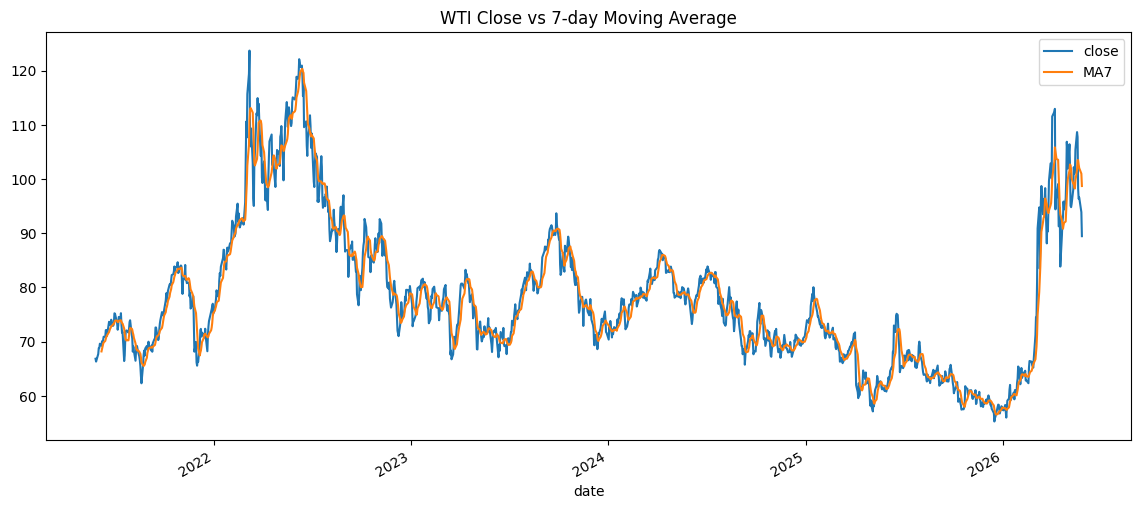

In [35]:
import matplotlib.pyplot as plt

wti[["close", "MA7"]].plot(figsize=(14,6))
plt.title("WTI Close vs 7-day Moving Average")
plt.show()

Copied plotly - from internet to just see how it work

In [36]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


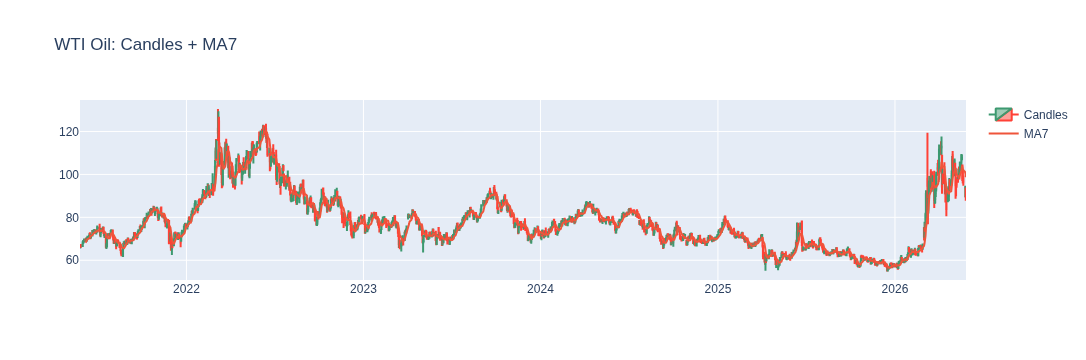

In [37]:
import plotly.graph_objects as go

fig = go.Figure()

# Candles
fig.add_trace(go.Candlestick(
    x=wti.index,
    open=wti["open"],
    high=wti["high"],
    low=wti["low"],
    close=wti["close"],
    name="Candles"
))

# Moving average
wti["MA7"] = wti["close"].rolling(7).mean()

fig.add_trace(go.Scatter(
    x=wti.index,
    y=wti["MA7"],
    mode="lines",
    name="MA7"
))

fig.update_layout(
    title="WTI Oil: Candles + MA7",
    xaxis_rangeslider_visible=False
)

fig.show()

In [38]:
#2 30-day moving average
wti['MA30'] = wti['close'].rolling(30).mean()

Text(0.5, 1.0, 'WTI close vs 30-day Moving Average')

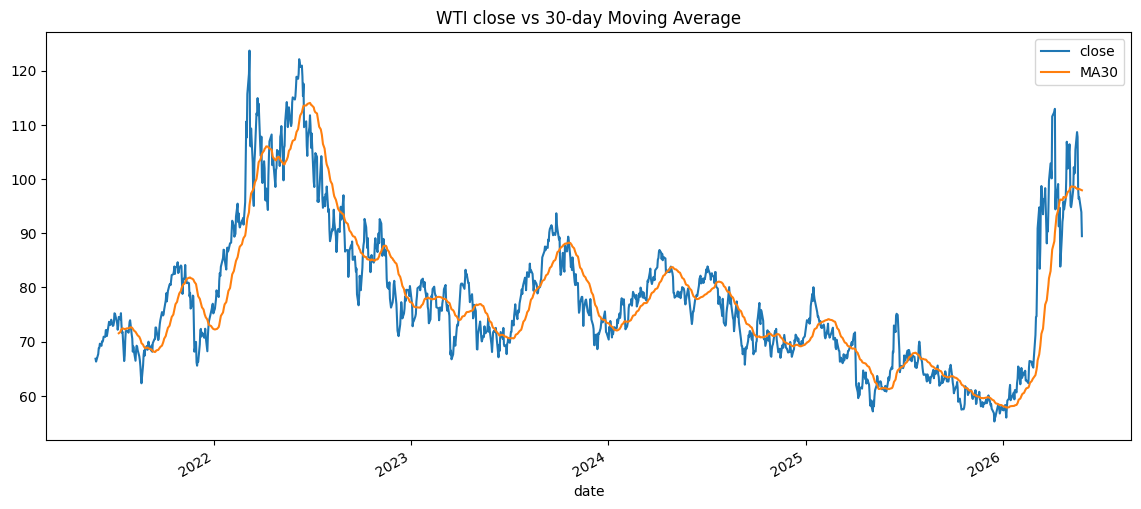

In [39]:
wti[['close', 'MA30']].plot(figsize= (14,6))
plt.title("WTI close vs 30-day Moving Average")

Text(0.5, 1.0, 'WTI close vs 200-day Moving Average')

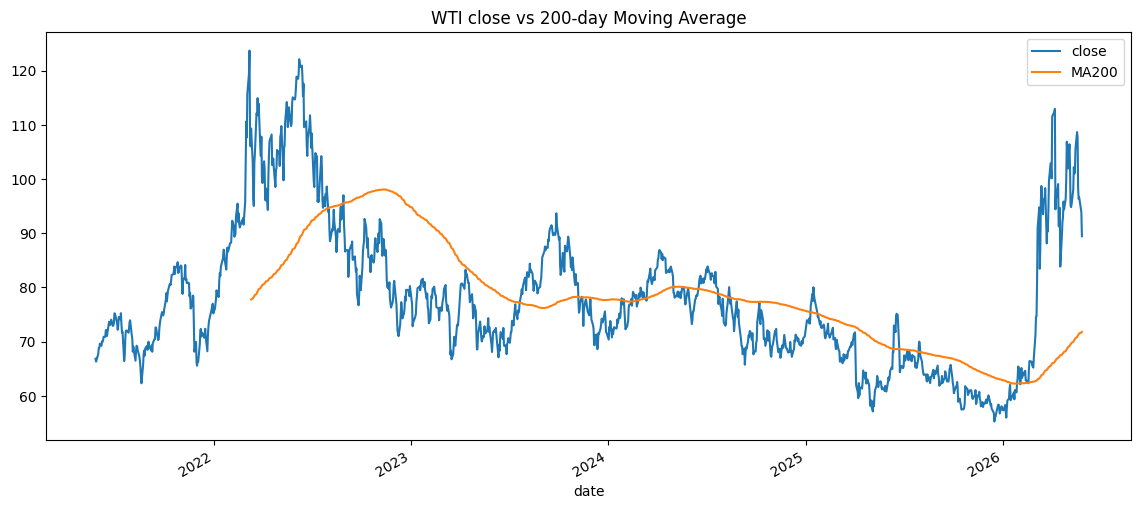

In [40]:
#2 30-day moving average
wti['MA200'] = wti['close'].rolling(200).mean()
wti[['close', 'MA200']].plot(figsize= (14,6))
plt.title("WTI close vs 200-day Moving Average")

<Axes: xlabel='date'>

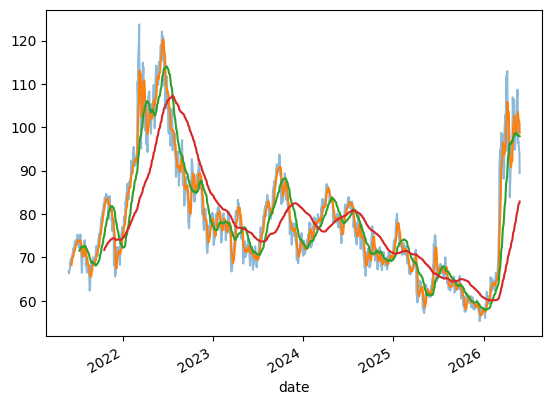

In [41]:
wti["close"].plot(alpha=0.5)
wti["close"].rolling(7).mean().plot()
wti["close"].rolling(30).mean().plot()
wti["close"].rolling(100).mean().plot()

Then ask yourself:

1. When do crossovers happen?
2. When does trend change?
3. When does volatility increase?

# How traders use MA crossover signals (Golden Cross / Death Cross)

If short-term price behavior becomes stronger than long-term behavior, momentum may be changing.

1. Golden Cross (Bullish Signal)

    Happens when:
Short-term MA crosses ABOVE long-term MA

    Example:
50 MA crosses above 200 MA

    This suggests:
recent prices are improving
momentum becoming bullish
trend may be turning upward

2. Death Cross (Bearish Signal)

    Happens when:
Short-term MA crosses BELOW long-term MA

    Example:
50 MA crosses below 200 MA

    This suggests:
recent prices weakening
bearish momentum increasing
possible downtrend

## Why traders use it?
Because it helps avoid reacting to random daily noise.

Instead of: "price went up today buy!!"

they ask: "has the medium-term trend changed?"

* But there is a BIG limitation

    Crossovers are lagging indicators. Why?

    Because moving averages use past data.

    So: by the time crossover happens
part of move already occurred
Example

    - Oil crashes.
    - Then starts recovering.

    1. The 50 MA may cross 200 MA much later.

    2. So traders sacrifice - early entry - for - higher confidence

- Real-world tradeoff 
1. Fast MA - reacts early - more false signals - noisy	
2. Slow MA - reacts late - more stable - smoother

# For YOUR oil project

This is VERY valuable.

You can analyze:

When did oil enter bullish phases?
When did crisis regimes start?
Did volatility increase before crossover?
How long do trends sustain?

This turns your project into market intelligence analysis

In [45]:
wti["MA_50"] = wti["close"].rolling(50).mean()
wti["MA_200"] = wti["close"].rolling(200).mean()

<Axes: xlabel='date'>

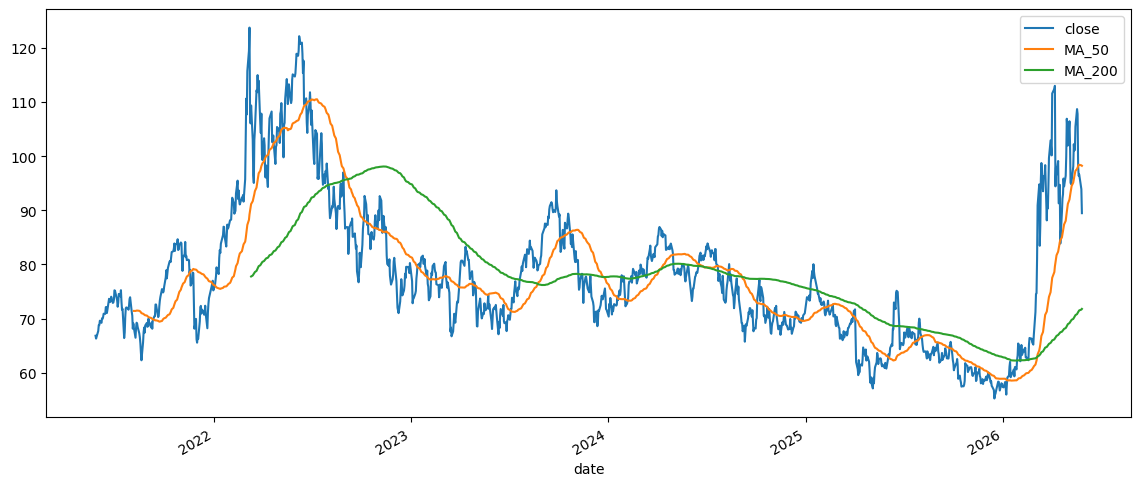

In [47]:
wti[["close", "MA_50", "MA_200"]].plot(figsize=(14,6))

A smoothed comparison between short-term and long-term market behavior to detect possible trend regime changes.

# Golden Cross
MA_50 moves above MA_200

# Death Cross
MA_50 moves below MA_200